# Feature Engineering

Feature Engineering is the process of transforming raw data into useful inputs(features) to improve the performance of supervised learning models.
It is done by selecting, transforming and manipulating raw data into useful features.
It is also necessary to design and train new machine learning features so it can tackle new tasks.

In feature engineering, a feature is basically an individual measurable property, characteristic, or attribute of the data that can be used for analysis or to train a machine learning model.Features represent the raw information in a form that a model can understand.

Good features help models learn better.
Bad or Irrelevant features can reduce accuracy.
For Example:
If you are predicting the price of a car,It's features could be:
- Brand
- Engine Size
- Fuel Type
- Horsepower etc.

#### In Feature Engineering, features are often handled through four main processes.They are:
- Feature Transformation 
- Feature Construction 
- Feature Selection 
- Feature Extraction

## Feature Transformation: 
Feature transformation is the process of converting features from their original format into a more suitable format to improve model performance.
Techniques used in this process are Normalization, Standardization, Log Transformation, Binning etc.

#### Handling Missing Value:
Missing values happen when some data points are not recorded. Handling them is crucial because many ML models cannot process NaN or blank values.

To build an unbiased model and for accuracy,we have to handle missing values.

It can be handled in various ways:
- Remove rows: Drop rows with missing data.

- Remove columns: Drop entire feature if mostly missing.

- Impute missing values: Replace missing value with mean/median/mode of the feature.

1.Mean --> If the data is normally distributed and has no outliers.

2.Median --> if the data is skewed or has outliers.

3.Mode --> simple categorical imputation.

4.KNN --> preserve the structure and relationships in the data, when the dataaset is not too large. 	

In [1]:
import pandas as pd
load=pd.read_csv("Retail_product_dataset.csv")
load.head(15)
df = pd.DataFrame(load)
print(df)
af=pd.DataFrame(load)

     Category   Price    Rating         Stock  Discount
0         NaN  5548.0  1.870322           NaN       0.0
1         NaN  3045.0  4.757798           NaN      38.0
2         NaN  4004.0       NaN      In Stock       0.0
3         NaN  4808.0  1.492085           NaN      33.0
4         NaN  1817.0       NaN  Out of Stock      23.0
...       ...     ...       ...           ...       ...
4357      NaN  4436.0  4.728335           NaN      49.0
4358        B  6236.0       NaN  Out of Stock       4.0
4359      NaN  3283.0       NaN  Out of Stock       9.0
4360        D  2999.0  4.425995           NaN      40.0
4361      NaN     NaN  2.184471           NaN       0.0

[4362 rows x 5 columns]


In [2]:
print(af)

     Category   Price    Rating         Stock  Discount
0         NaN  5548.0  1.870322           NaN       0.0
1         NaN  3045.0  4.757798           NaN      38.0
2         NaN  4004.0       NaN      In Stock       0.0
3         NaN  4808.0  1.492085           NaN      33.0
4         NaN  1817.0       NaN  Out of Stock      23.0
...       ...     ...       ...           ...       ...
4357      NaN  4436.0  4.728335           NaN      49.0
4358        B  6236.0       NaN  Out of Stock       4.0
4359      NaN  3283.0       NaN  Out of Stock       9.0
4360        D  2999.0  4.425995           NaN      40.0
4361      NaN     NaN  2.184471           NaN       0.0

[4362 rows x 5 columns]


In [3]:
load.info()

<class 'pandas.DataFrame'>
RangeIndex: 4362 entries, 0 to 4361
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Category  1614 non-null   str    
 1   Price     4188 non-null   float64
 2   Rating    2312 non-null   float64
 3   Stock     3010 non-null   str    
 4   Discount  3970 non-null   float64
dtypes: float64(3), str(2)
memory usage: 170.5 KB


In [4]:
df = pd.DataFrame(load)


In [5]:
print(df.isnull().sum())  # Shows count of missing values per column

Category    2748
Price        174
Rating      2050
Stock       1352
Discount     392
dtype: int64


### By Removing Rows:

In [6]:
df_dropped_rows = df.dropna()
print("\nDataFrame after dropping rows with missing values:")
print(df_dropped_rows)
df.dropna(inplace=True)




DataFrame after dropping rows with missing values:
     Category   Price    Rating         Stock  Discount
6           C   667.0  3.668341      In Stock      41.0
7           A  7125.0  4.983998  Out of Stock       7.0
8           A  2777.0  2.678384      In Stock       6.0
11          A  3772.0  4.890750      In Stock      45.0
15          A  7936.0  3.032832      In Stock      44.0
...       ...     ...       ...           ...       ...
4313        A  4167.0  2.432036  Out of Stock      22.0
4320        C  7630.0  3.475273      In Stock       0.0
4333        D  2424.0  4.716295      In Stock      49.0
4342        D  9847.0  3.667649  Out of Stock      49.0
4343        B   843.0  2.752754  Out of Stock      48.0

[540 rows x 5 columns]


In [7]:
#Now Let's check again if there is any missing values:
print(df.isnull().sum())


Category    0
Price       0
Rating      0
Stock       0
Discount    0
dtype: int64


### Imputation with mean/mode/median:

In [8]:
# Impute missing values with the mean

af_mean = af
af_mean['Rating'] = af_mean['Rating'].fillna(af_mean['Rating'].mean())
af_mean['Price'] = af_mean['Price'].fillna(af_mean['Price'].mean())
af_mean['Discount'] = af_mean['Discount'].fillna(af_mean['Discount'].mean())
af_mean.head(10)

,Category,Price,Rating,Stock,Discount
0,NaN,5548.0,1.870322,NaN,0.000000
1,NaN,3045.0,4.757798,NaN,38.000000
2,NaN,4004.0,3.038293,In Stock,0.000000
3,NaN,4808.0,1.492085,NaN,33.000000
4,NaN,1817.0,3.038293,Out of Stock,23.000000
5,NaN,3522.0,3.038293,NaN,24.516625
6,C,667.0,3.668341,In Stock,41.000000
7,A,7125.0,4.983998,Out of Stock,7.000000
8,A,2777.0,2.678384,In Stock,6.000000
9,NaN,463.0,4.626187,NaN,3.000000


### Handeling Categorical Value
Handling categorical data in feature engineering primarily involves converting non-numeric categories into a numerical format that machine learning algorithms can process.

In [9]:
# Make a copy to avoid warnings
af_mode = af.copy()

# Fill missing categorical values with the **mode scalar**
af_mode['Category'] = af_mode['Category'].fillna(af_mode['Category'].mode()[0])
af_mode['Stock'] = af_mode['Stock'].fillna(af_mode['Stock'].mode()[0])


af_mode.head(10)

,Category,Price,Rating,Stock,Discount
0,C,5548.0,1.870322,In Stock,0.000000
1,C,3045.0,4.757798,In Stock,38.000000
2,C,4004.0,3.038293,In Stock,0.000000
3,C,4808.0,1.492085,In Stock,33.000000
4,C,1817.0,3.038293,Out of Stock,23.000000
5,C,3522.0,3.038293,In Stock,24.516625
6,C,667.0,3.668341,In Stock,41.000000
7,A,7125.0,4.983998,Out of Stock,7.000000
8,A,2777.0,2.678384,In Stock,6.000000
9,C,463.0,4.626187,In Stock,3.000000


# Label Encoding  vs Ordinal Encoding
Label Encoding: It converts each category into unique integer.It is used mainly for nominal categorical data i.e. data with no order.
Ordinal Encoding:It converts categories to integers according to a meaningful order.It is mainly for ordinal categorical data i.e. data with order. 

In [10]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
af['Category_label']=le.fit_transform(af['Category'])
af.head(10)



,Category,Price,Rating,Stock,Discount,Category_label
0,NaN,5548.0,1.870322,NaN,0.000000,4
1,NaN,3045.0,4.757798,NaN,38.000000,4
2,NaN,4004.0,3.038293,In Stock,0.000000,4
3,NaN,4808.0,1.492085,NaN,33.000000,4
4,NaN,1817.0,3.038293,Out of Stock,23.000000,4
5,NaN,3522.0,3.038293,NaN,24.516625,4
6,C,667.0,3.668341,In Stock,41.000000,2
7,A,7125.0,4.983998,Out of Stock,7.000000,0
8,A,2777.0,2.678384,In Stock,6.000000,0
9,NaN,463.0,4.626187,NaN,3.000000,4


This is an example of label encoding.Here, We converted string labels into integer. 'Fit' means It will train with the only data we have.After encoding the order is done in lexicographical order.

In [11]:
af['Category'] = af['Category'].fillna('Unknown')
af['Stock'] = af['Stock'].fillna('Unknown')
af.head(10)

,Category,Price,Rating,Stock,Discount,Category_label
0,Unknown,5548.0,1.870322,Unknown,0.000000,4
1,Unknown,3045.0,4.757798,Unknown,38.000000,4
2,Unknown,4004.0,3.038293,In Stock,0.000000,4
3,Unknown,4808.0,1.492085,Unknown,33.000000,4
4,Unknown,1817.0,3.038293,Out of Stock,23.000000,4
5,Unknown,3522.0,3.038293,Unknown,24.516625,4
6,C,667.0,3.668341,In Stock,41.000000,2
7,A,7125.0,4.983998,Out of Stock,7.000000,0
8,A,2777.0,2.678384,In Stock,6.000000,0
9,Unknown,463.0,4.626187,Unknown,3.000000,4


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('stock_ohe', OneHotEncoder(handle_unknown='ignore'), ['Stock'])
    ],
    remainder='passthrough'   # Keep other columns as they are
)

# Apply transformation
transformed_data = preprocessor.fit_transform(af)

# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Convert to DataFrame
af_encoded = pd.DataFrame(transformed_data, columns=feature_names)

print(af_encoded.head())

  stock_ohe__Stock_In Stock stock_ohe__Stock_Out of Stock  \
0                       0.0                           0.0   
1                       0.0                           0.0   
2                       1.0                           0.0   
3                       0.0                           0.0   
4                       0.0                           1.0   

  stock_ohe__Stock_Unknown remainder__Category remainder__Price  \
0                      1.0             Unknown           5548.0   
1                      1.0             Unknown           3045.0   
2                      0.0             Unknown           4004.0   
3                      1.0             Unknown           4808.0   
4                      0.0             Unknown           1817.0   

  remainder__Rating remainder__Discount remainder__Category_label  
0          1.870322                 0.0                         4  
1          4.757798                38.0                         4  
2          3.038293       

### Feature Scaling
Feature Scaling is a preprocessing technique in machine learning used to standardize or normalize numerical features so that they are on a similar scale, improving model performance.Some of the methods for Scaling are **Min–Max Scaling (Normalization) ,Standardization (Z-Score Scaling) ,Robust Scaling ,Max Absolute Scaling ,Unit Vector Scaling (L1 / L2 Normalization)**

In [13]:

data = {
    'Feature_1': af['Rating'],
    'Feature_2': af['Discount']
}

af = pd.DataFrame(data)
print("Original Dataset:\n", af)

Original Dataset:
       Feature_1  Feature_2
0      1.870322        0.0
1      4.757798       38.0
2      3.038293        0.0
3      1.492085       33.0
4      3.038293       23.0
...         ...        ...
4357   4.728335       49.0
4358   3.038293        4.0
4359   3.038293        9.0
4360   4.425995       40.0
4361   2.184471        0.0

[4362 rows x 2 columns]


In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()


af_standard = pd.DataFrame(standard_scaler.fit_transform(af), columns=af.columns)
af_minmax = pd.DataFrame(minmax_scaler.fit_transform(af), columns=af.columns)



print("\nStandard Scaled Data:\n", af_standard)
print("\nMinMax Scaled Data:\n", af_minmax)



Standard Scaled Data:
          Feature_1  Feature_2
0    -1.403784e+00  -1.791418
1     2.066674e+00   0.985224
2    -5.337509e-16  -1.791418
3    -1.858387e+00   0.619876
4    -5.337509e-16  -0.110819
...            ...        ...
4357  2.031262e+00   1.788988
4358 -5.337509e-16  -1.499140
4359 -5.337509e-16  -1.133792
4360  1.667880e+00   1.131363
4361 -1.026208e+00  -1.791418

[4362 rows x 2 columns]

MinMax Scaled Data:
       Feature_1  Feature_2
0      0.217628   0.000000
1      0.939957   0.775510
2      0.509806   0.000000
3      0.123008   0.673469
4      0.509806   0.469388
...         ...        ...
4357   0.932586   1.000000
4358   0.509806   0.081633
4359   0.509806   0.183673
4360   0.856953   0.816327
4361   0.296215   0.000000

[4362 rows x 2 columns]


In [15]:
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Handling Outliers:
Handling outliers in data cleaning involves identifying and managing data points that deviate significantly from the rest of the dataset

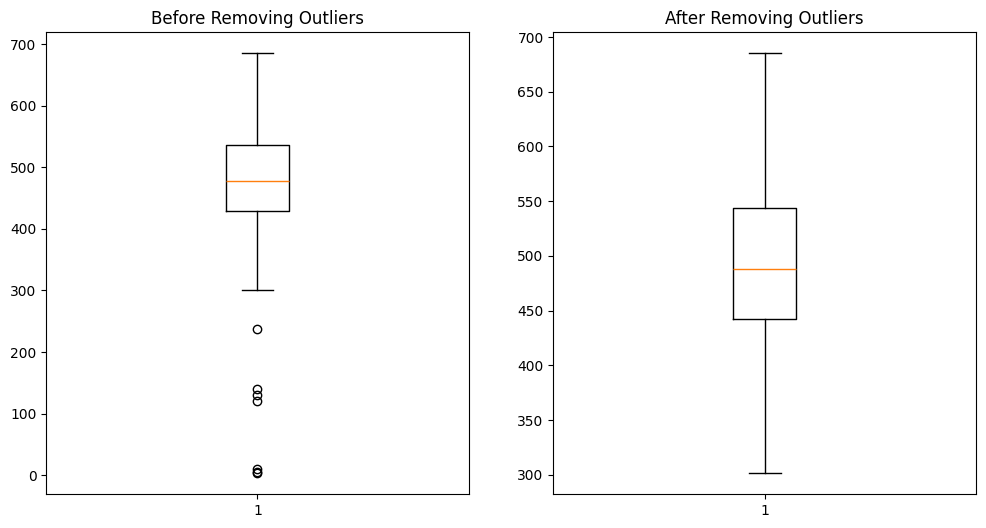

Data after removing outliers:
        Value
0  549.671415
1  486.173570
2  564.768854
3  652.302986
4  476.584663


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generate some random data
np.random.seed(42)
data = np.random.normal(loc=500, scale=100, size=100)  # Normal distribution

# Add extreme outliers (including very low values)
outliers = np.array([10, 120, 130, 5, 140, 3])
data_with_outliers = np.concatenate([data, outliers])

# Convert to DataFrame
df = pd.DataFrame({'Value': data_with_outliers})

# Calculate Q1, Q3, and IQR
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df_filtered = df[(df['Value'] >= lower_bound) & (df['Value'] <= upper_bound)]

# Plot before and after removing outliers
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.boxplot(df['Value'])
ax1.set_title("Before Removing Outliers")

ax2.boxplot(df_filtered['Value'])
ax2.set_title("After Removing Outliers")

plt.show()

print("Data after removing outliers:")
print(df_filtered.head())

In [17]:
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
print(af.columns)

Index(['Feature_1', 'Feature_2'], dtype='str')


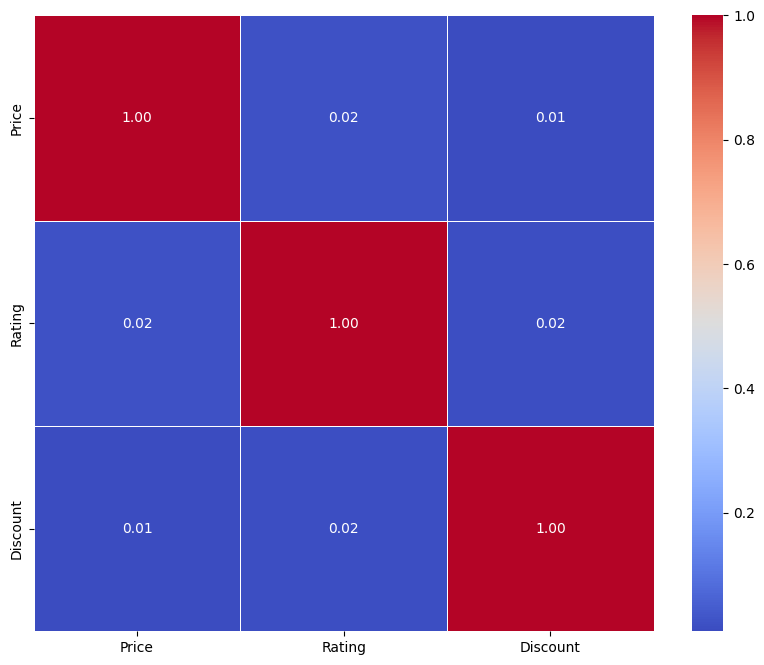

Columns to drop due to high correlation: []
Remaining columns: Index(['Category', 'Price', 'Rating', 'Stock', 'Discount'], dtype='str')


In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

af = pd.read_csv("Retail_product_dataset.csv")
af.columns = af.columns.str.strip()  
numeric_cols = af.select_dtypes(include='number').columns

corr_matrix = af[numeric_cols].corr().abs()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.9
to_drop = [column for column in upper.columns if any(upper[column] > corr_threshold)]
print("Columns to drop due to high correlation:", to_drop)

af_reduced = af.drop(columns=to_drop)
print("Remaining columns:", af_reduced.columns)